In [ ]:
!pip -q install transformers datasets evaluate accelerate
!pip -q install scikit-learn pandas matplotlib seaborn

In [ ]:

import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random Seed Set:", SEED)

Random Seed Set: 42


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if device.type == "cpu":
    print("Running on CPU")
else:
    print("Running on GPU")

Device : cuda
Running on GPU


In [ ]:


import transformers

print("Transformers :", transformers.__version__)
print("Torch        :", torch.__version__)
print("Pandas       :", pd.__version__)

Transformers : 5.14.1
Torch        : 2.11.0+cu128
Pandas       : 2.2.2


In [ ]:
from google.colab import files

uploaded = files.upload()

# Replace with your uploaded file name if different
df = pd.read_csv("fake_or_real_news.csv")

print("Dataset Loaded Successfully")
print("Shape :", df.shape)

Saving fake_or_real_news.csv to fake_or_real_news (2).csv
Dataset Loaded Successfully
Shape : (6335, 4)


In [ ]:
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  

Columns:
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Coun

In [ ]:
print(df.isnull().sum())

print("\nTotal Missing Values:",
      df.isnull().sum().sum())

Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

Total Missing Values: 0


In [ ]:
df = df.dropna()

print("New Shape :", df.shape)

New Shape : (6335, 4)


In [ ]:
print("Before :", len(df))

df = df.drop_duplicates(subset=["title", "text"])

print("After :", len(df))

Before : 6335
After : 6306


label
REAL    3154
FAKE    3152
Name: count, dtype: int64


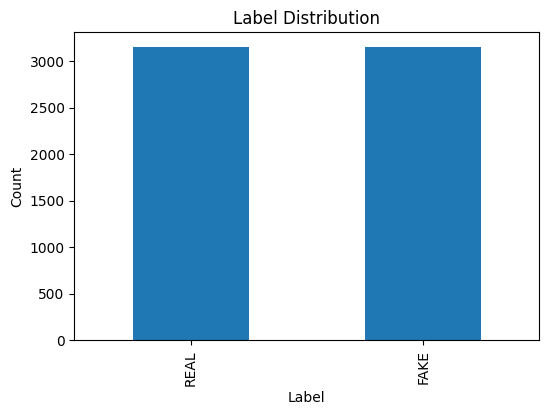

In [ ]:
print(df["label"].value_counts())

plt.figure(figsize=(6,4))

df["label"].value_counts().plot(
    kind="bar"
)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [ ]:
df["content"] = (
    df["title"].fillna("") +
    " " +
    df["text"].fillna("")
)

print(df["content"].head())

0    You Can Smell Hillary’s Fear Daniel Greenfield...
1    Watch The Exact Moment Paul Ryan Committed Pol...
2    Kerry to go to Paris in gesture of sympathy U....
3    Bernie supporters on Twitter erupt in anger ag...
4    The Battle of New York: Why This Primary Matte...
Name: content, dtype: object


In [ ]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["content"] = df["content"].apply(clean_text)

print(df["content"].head())

0    you can smell hillary s fear daniel greenfield...
1    watch the exact moment paul ryan committed pol...
2    kerry to go to paris in gesture of sympathy u ...
3    bernie supporters on twitter erupt in anger ag...
4    the battle of new york why this primary matter...
Name: content, dtype: object


In [ ]:
print("Before:", len(df))

df = df.drop_duplicates(subset=["content"], keep="first").reset_index(drop=True)

print("After :", len(df))

print("Removed :", len(df))

Before: 6306
After : 6304
Removed : 6304


In [ ]:
before = len(df)

df = df.drop_duplicates(subset=["content"], keep="first").reset_index(drop=True)

after = len(df)

print("Before :", before)
print("After  :", after)
print("Removed:", before - after)

Before : 6304
After  : 6304
Removed: 0


In [ ]:
# Convert labels to integers

df["label"] = df["label"].str.upper()

df["label"] = df["label"].map({
    "FAKE": 0,
    "REAL": 1
})

print(df["label"].value_counts())

label
1    3153
0    3151
Name: count, dtype: int64


In [ ]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["content"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Train :", len(train_texts))
print("Validation :", len(val_texts))
print("Test :", len(test_texts))

Train : 5043
Validation : 630
Test : 631


In [ ]:
train_set = set(train_texts.tolist())
val_set = set(val_texts.tolist())
test_set = set(test_texts.tolist())

print("Train ↔ Validation :", len(train_set & val_set))
print("Train ↔ Test :", len(train_set & test_set))
print("Validation ↔ Test :", len(val_set & test_set))

if len(train_set & val_set) == 0 and len(train_set & test_set) == 0 and len(val_set & test_set) == 0:
    print("\n✅ No Data Leakage Found")
else:
    print("\n⚠️ Warning: Data Leakage Detected")

Train ↔ Validation : 0
Train ↔ Test : 0
Validation ↔ Test : 0

✅ No Data Leakage Found


In [ ]:
MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer Loaded Successfully")

Tokenizer Loaded Successfully


In [ ]:
MAX_LEN = 128

In [ ]:
# ==========================================
# Custom Dataset
# ==========================================

class FakeNewsDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:

train_dataset = FakeNewsDataset(
    train_texts,
    train_labels,
    tokenizer,
    MAX_LEN
)

val_dataset = FakeNewsDataset(
    val_texts,
    val_labels,
    tokenizer,
    MAX_LEN
)

test_dataset = FakeNewsDataset(
    test_texts,
    test_labels,
    tokenizer,
    MAX_LEN
)

print("Datasets Created Successfully")

Datasets Created Successfully


In [ ]:

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches     :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches      :", len(test_loader))

Train batches     : 158
Validation batches: 20
Test batches      : 20


In [ ]:

batch = next(iter(train_loader))

print("Input IDs Shape      :", batch["input_ids"].shape)
print("Attention Mask Shape :", batch["attention_mask"].shape)
print("Labels Shape         :", batch["labels"].shape)

print("\nSample Label:", batch["labels"][0].item())
print("First 20 Token IDs:", batch["input_ids"][0][:20])

Input IDs Shape      : torch.Size([32, 128])
Attention Mask Shape : torch.Size([32, 128])
Labels Shape         : torch.Size([32])

Sample Label: 1
First 20 Token IDs: tensor([  101,  2044,  8112, 16302,  1996,  2279,  3537,  2740, 11376,  1996,
        15184,  2729,  2552,  2038,  2085,  5175,  2093,  4259,  2457,  7860])


In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)

print(model.__class__.__name__)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification


In [ ]:
from torch.optim import AdamW

LEARNING_RATE = 1e-5

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.02
)

print("Optimizer Ready")

Optimizer Ready


In [ ]:
from transformers import get_linear_schedule_with_warmup

EPOCHS = 10

total_steps = len(train_loader) * EPOCHS

warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("Total Steps :", total_steps)
print("Warmup Steps :", warmup_steps)

Total Steps : 1580
Warmup Steps : 158


In [ ]:
best_val_loss = float("inf")

patience = 5
patience_counter = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

print("Training Variables Initialized")

Training Variables Initialized


In [ ]:
MAX_GRAD_NORM = 1.0

print("Gradient Clipping:", MAX_GRAD_NORM)

Gradient Clipping: 1.0


In [ ]:
BEST_MODEL_PATH = "best_bert_model.pt"

print(BEST_MODEL_PATH)

best_bert_model.pt


In [ ]:


from tqdm.auto import tqdm
import torch

def train_epoch(model, dataloader, optimizer, scheduler, device):

    model.train()

    total_loss = 0
    correct_predictions = 0
    total_examples = 0

    for batch in tqdm(dataloader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        correct_predictions += torch.sum(preds == labels)

        total_examples += labels.size(0)

    avg_loss = total_loss / len(dataloader)

    accuracy = correct_predictions.double() / total_examples

    return avg_loss, accuracy.item()

In [ ]:

def eval_epoch(model, dataloader, device):

    model.eval()

    total_loss = 0
    correct_predictions = 0
    total_examples = 0

    predictions = []
    true_labels = []

    with torch.no_grad():

        for batch in tqdm(dataloader):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct_predictions += torch.sum(preds == labels)

            total_examples += labels.size(0)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    accuracy = correct_predictions.double() / total_examples

    return avg_loss, accuracy.item(), predictions, true_labels

In [ ]:

history = []

best_val_loss = float("inf")
patience = 2
counter = 0

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-"*50)

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        device
    )

    val_loss, val_acc, _, _ = eval_epoch(
        model,
        val_loader,
        device
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc
    })

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        counter = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("✅ Best Model Saved")

    else:

        counter += 1

        print(f"EarlyStopping Counter: {counter}/{patience}")

        if counter >= patience:

            print("🛑 Early Stopping")

            break


Epoch 1/10
--------------------------------------------------


  0%|          | 0/158 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Train Loss : 0.5341
Train Acc  : 0.7252
Val Loss   : 0.3425
Val Acc    : 0.8651
✅ Best Model Saved

Epoch 2/10
--------------------------------------------------


  0%|          | 0/158 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

Train Loss : 0.0671
Train Acc  : 0.9786
Val Loss   : 0.2177
Val Acc    : 0.9381
EarlyStopping Counter: 1/2

Epoch 5/10
--------------------------------------------------


  0%|          | 0/158 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Train Loss : 0.0303
Train Acc  : 0.9923
Val Loss   : 0.2254
Val Acc    : 0.9444
EarlyStopping Counter: 2/2
🛑 Early Stopping


In [ ]:
model.load_state_dict(torch.load(BEST_MODEL_PATH))

model.to(device)

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


In [ ]:
test_loss, test_accuracy, predictions, true_labels = eval_epoch(
    model,
    test_loader,
    device
)

print("="*50)
print("Test Loss     :", round(test_loss,4))
print("Test Accuracy :", round(test_accuracy*100,2),"%")
print("="*50)

  0%|          | 0/20 [00:00<?, ?it/s]

Test Loss     : 0.1112
Test Accuracy : 96.04 %


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predictions,
        target_names=["FAKE","REAL"]
    )
)

              precision    recall  f1-score   support

        FAKE       0.96      0.97      0.96       315
        REAL       0.96      0.96      0.96       316

    accuracy                           0.96       631
   macro avg       0.96      0.96      0.96       631
weighted avg       0.96      0.96      0.96       631



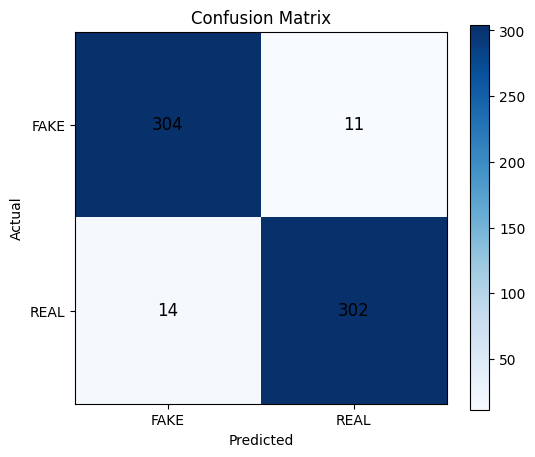

In [ ]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["FAKE","REAL"])
plt.yticks([0,1],["FAKE","REAL"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i,j]),
            ha="center",
            va="center",
            color="black",
            fontsize=12
        )

plt.show()

In [ ]:

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(true_labels, predictions)

precision = precision_score(true_labels, predictions)

recall = recall_score(true_labels, predictions)

f1 = f1_score(true_labels, predictions)

print("Accuracy :", round(accuracy*100,2),"%")
print("Precision:", round(precision*100,2),"%")
print("Recall   :", round(recall*100,2),"%")
print("F1 Score :", round(f1*100,2),"%")

Accuracy : 96.04 %
Precision: 96.49 %
Recall   : 95.57 %
F1 Score : 96.03 %


In [ ]:
print(history)

[{'epoch': 1, 'train_loss': 0.5340567934739439, 'train_accuracy': 0.7251635930993456, 'val_loss': 0.3425364889204502, 'val_accuracy': 0.8650793650793651}, {'epoch': 2, 'train_loss': 0.21047548383851594, 'train_accuracy': 0.924053142970454, 'val_loss': 0.2643441231921315, 'val_accuracy': 0.9015873015873016}, {'epoch': 3, 'train_loss': 0.12038441331868496, 'train_accuracy': 0.9615308348205434, 'val_loss': 0.21406835941597818, 'val_accuracy': 0.9206349206349206}, {'epoch': 4, 'train_loss': 0.06714014094794475, 'train_accuracy': 0.9785841760856633, 'val_loss': 0.21767473437357693, 'val_accuracy': 0.9380952380952381}, {'epoch': 5, 'train_loss': 0.03025691971459862, 'train_accuracy': 0.992266508030934, 'val_loss': 0.22536557263229043, 'val_accuracy': 0.9444444444444444}]


In [ ]:
import pandas as pd

history_df = pd.DataFrame(history)

print(history_df)

print(history_df.columns)

   epoch  train_loss  train_accuracy  val_loss  val_accuracy
0      1    0.534057        0.725164  0.342536      0.865079
1      2    0.210475        0.924053  0.264344      0.901587
2      3    0.120384        0.961531  0.214068      0.920635
3      4    0.067140        0.978584  0.217675      0.938095
4      5    0.030257        0.992267  0.225366      0.944444
Index(['epoch', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy'], dtype='object')


In [ ]:
print(history)

[{'epoch': 1, 'train_loss': 0.5340567934739439, 'train_accuracy': 0.7251635930993456, 'val_loss': 0.3425364889204502, 'val_accuracy': 0.8650793650793651}, {'epoch': 2, 'train_loss': 0.21047548383851594, 'train_accuracy': 0.924053142970454, 'val_loss': 0.2643441231921315, 'val_accuracy': 0.9015873015873016}, {'epoch': 3, 'train_loss': 0.12038441331868496, 'train_accuracy': 0.9615308348205434, 'val_loss': 0.21406835941597818, 'val_accuracy': 0.9206349206349206}, {'epoch': 4, 'train_loss': 0.06714014094794475, 'train_accuracy': 0.9785841760856633, 'val_loss': 0.21767473437357693, 'val_accuracy': 0.9380952380952381}, {'epoch': 5, 'train_loss': 0.03025691971459862, 'train_accuracy': 0.992266508030934, 'val_loss': 0.22536557263229043, 'val_accuracy': 0.9444444444444444}]


In [ ]:
import pandas as pd

history_df = pd.DataFrame(history)

print(history_df)

   epoch  train_loss  train_accuracy  val_loss  val_accuracy
0      1    0.534057        0.725164  0.342536      0.865079
1      2    0.210475        0.924053  0.264344      0.901587
2      3    0.120384        0.961531  0.214068      0.920635
3      4    0.067140        0.978584  0.217675      0.938095
4      5    0.030257        0.992267  0.225366      0.944444


In [ ]:
!pip -q install scipy

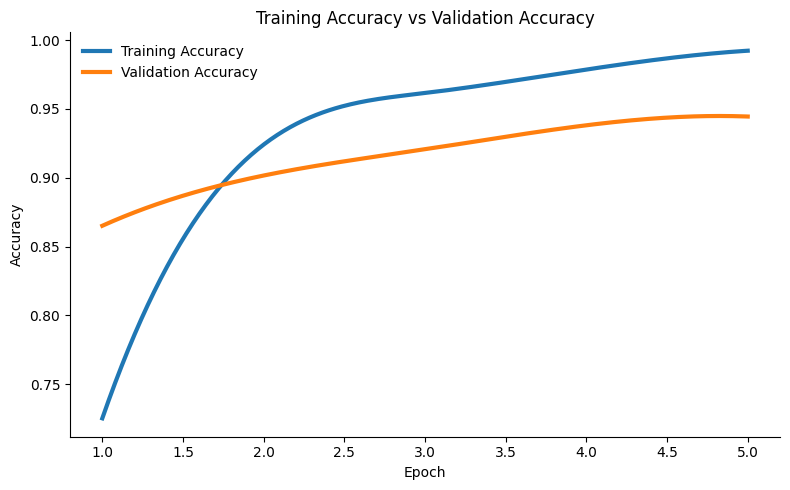

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

epochs = history_df["epoch"].values
train_acc = history_df["train_accuracy"].values
val_acc = history_df["val_accuracy"].values

# Smooth curve
x_new = np.linspace(epochs.min(), epochs.max(), 300)

train_smooth = make_interp_spline(epochs, train_acc, k=3)(x_new)
val_smooth = make_interp_spline(epochs, val_acc, k=3)(x_new)

plt.figure(figsize=(8,5))

plt.plot(x_new, train_smooth, linewidth=3, label="Training Accuracy")
plt.plot(x_new, val_smooth, linewidth=3, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Validation Accuracy")

# Grid / Box remove
plt.grid(False)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

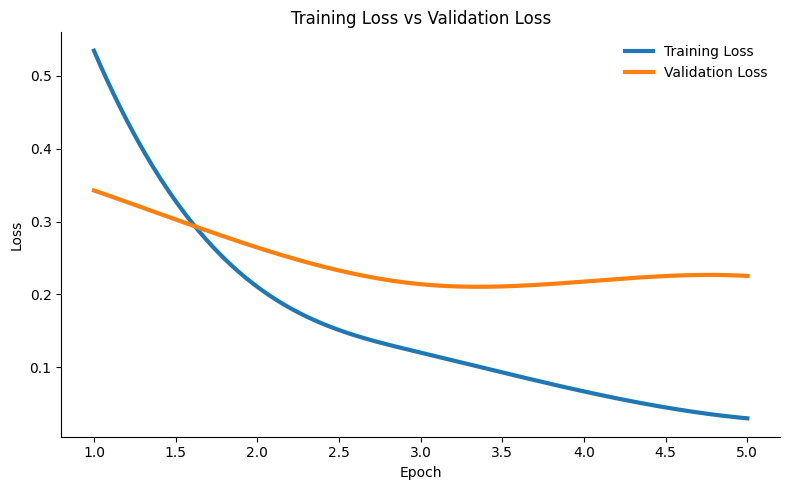

In [ ]:
train_loss = history_df["train_loss"].values
val_loss = history_df["val_loss"].values

train_loss_smooth = make_interp_spline(epochs, train_loss, k=3)(x_new)
val_loss_smooth = make_interp_spline(epochs, val_loss, k=3)(x_new)

plt.figure(figsize=(8,5))

plt.plot(x_new, train_loss_smooth, linewidth=3, label="Training Loss")
plt.plot(x_new, val_loss_smooth, linewidth=3, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")

plt.grid(False)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()